In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [5]:
df=pd.read_csv('CarPrice_Assignment.csv')
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [6]:
X=df[['enginesize', 'horsepower', 'citympg', 'highwaympg']]
y=df['price']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test_scaled)

Name:Lohith
Reg. No: 25013313
MODEL COEFFICIENTS:
     feature):    4523.40
     feature):    1694.22
     feature):    -392.57
     feature):    -816.36
   Intercept:   13223.41

MODEL PERFORMANCE:
         MSE: 16471505.90
        RMSE:    4058.51
   R-squared:       0.79
         MAE:    2892.63


Text(0.5, 1.0, 'Linearity Check: Actual vs P redicted Prices')

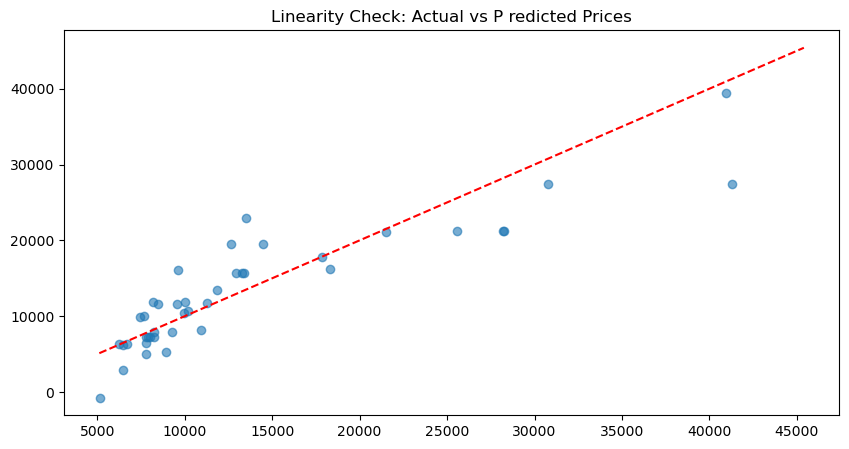

In [11]:
print('Name:Lohith')
print('Reg. No: 25013313')
print("MODEL COEFFICIENTS:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{'feature':>12}): {coef:>10.2f}")
print(f"{'Intercept':>12}: {model.intercept_:>10.2f}")

print("\nMODEL PERFORMANCE:")
print(f"{'MSE':>12}: {mean_squared_error(y_test, y_pred):>10.2f}")
print(f"{'RMSE':>12}: {np.sqrt(mean_squared_error(y_test, y_pred)):>10.2f}")
print(f"{'R-squared':>12}: {r2_score(y_test, y_pred):>10.2f}")
print(f"{'MAE':>12}: {mean_absolute_error(y_test, y_pred):>10.2f}")

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Linearity Check: Actual vs P redicted Prices")
    


Durbin-Watson Statistic: 2.28 
(Values close to indicate no autocorrelation)


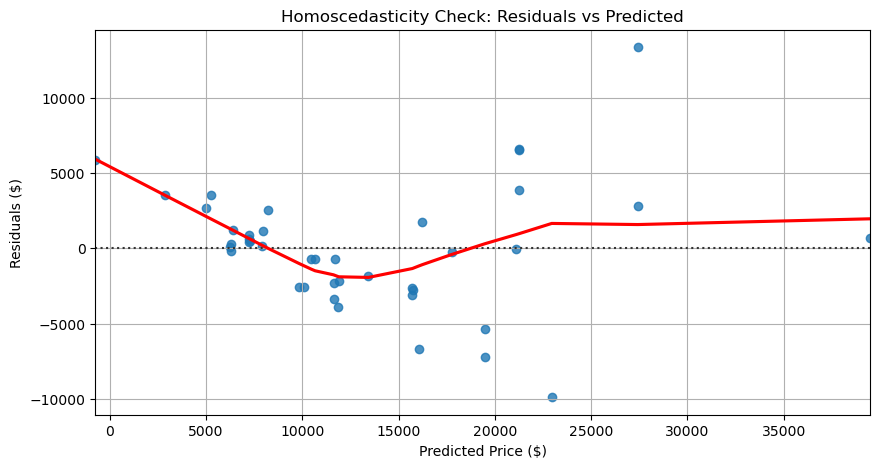

In [12]:
residuals = y_test - y_pred
dw_test = sm.stats.durbin_watson(residuals)
print(f"\nDurbin-Watson Statistic: {dw_test:.2f}", "\n(Values close to indicate no autocorrelation)")
plt.figure(figsize=(10,5))
sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.title("Homoscedasticity Check: Residuals vs Predicted")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residuals ($)")
plt.grid(True)
plt.show()

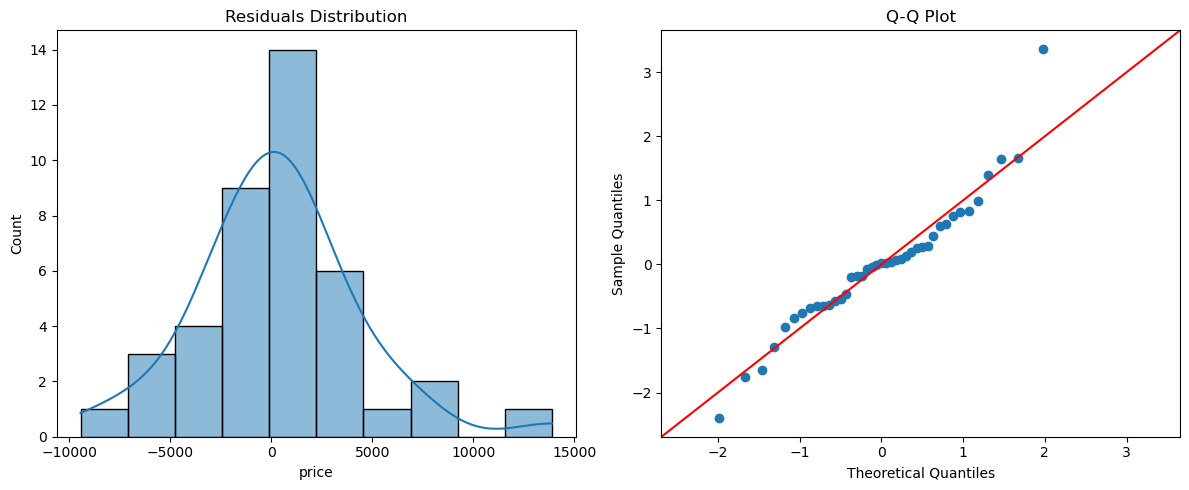

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(residuals, kde=True, ax=ax1)
ax1.set_title("Residuals Distribution")
sm.qqplot(residuals, line='45', fit=True, ax=ax2)
ax2.set_title("Q-Q Plot")
plt.tight_layout()